## Phase 1: The Binance Sandbox 

Target Chosen Pairs: Start with highly liquid pairs (using Binance's crypto equivalents, like EUR/USDT).

WebSocket Connection: Establish a stable stream to pull live Level 2 (market depth) data.

In-Memory Order Book: Reconstruct and update the live order book directly in your system's RAM for ultra-fast access.

Incorporate Fees: Integrate transaction fee data into your structure to calculate true "effective" execution rates.

https://developers.binance.com/docs/derivatives/usds-margined-futures/websocket-market-streams

## Phase 2: The Institutional Transition (Future Focus)

Swap the Data Connector: Once your data pipeline and logic are flawlessly processing the Binance feed, swap the Binance connection for Interactive Brokers (IBKR) or a similar institutional feed.

Preserve the Strategy Engine: Feed the new IBKR data into the exact same RAM-based order book and strategy logic you already built and tested in Phase 1.

In [1]:
import asyncio
import threading
import json
import time

from collections import defaultdict, deque

import websockets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

PAIRS = [
    "btcusdt",
    "ethusdt",
    "bnbusdt",
    "solusdt",
    "xrpusdt",
    "dogeusdt",
    "adausdt"
]

HISTORY_LEN = 120  # 120 seconds
order_books = {}
price_history = defaultdict(lambda: deque(maxlen=HISTORY_LEN))

STREAM_URL = (
    "wss://stream.binance.com:9443/stream?streams="
    + "/".join(f"{p}@depth5@100ms" for p in PAIRS)
)


def format_pair(stream_name):
    pair = stream_name.replace("@depth5@100ms", "").upper()

    # Handle common USDT-style pairs
    if pair.endswith("USDT"):
        base = pair[:-4]
        quote = "USD"
    else:
        base = pair[:3]
        quote = pair[3:]

    return f"{base} - {quote}"


async def binance_listener():
    async with websockets.connect(STREAM_URL) as ws:
        print(f"Connected to combined stream for: {', '.join(PAIRS)}")
        while True:
            try: 
                raw_data = await ws.recv()
                data = json.loads(raw_data)
                stream_name = data.get("stream")
                payload = data.get("data")
                if payload:
                    order_books[stream_name] = {
                        "bids": payload["bids"],
                        "asks": payload["asks"],
                    }
            
            except Exception as e:
                print("WebSocket Error:", e)
                await asyncio.sleep(1)

def start_listener_thread():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(binance_listener())

In [2]:
listener_thread = threading.Thread(target=start_listener_thread, daemon=True)
listener_thread.start()
print("Listener thread started")

Listener thread started


# A normalized short-term relative price dynamics

This graph is being definied as $$X_i(t) = \frac{ P_i(t) }{P_i(0)} - 1$$

- where $P_i(t)$ is the best bid price of asset i at time t
- $P_i(0)$ as the initial price of asset i at the start of the observation graph
- $X_i(t)$ as the percentage return of asset i

after that it it then got scaled to % which is $$R_i(t) = 100 * X_i(t)$$

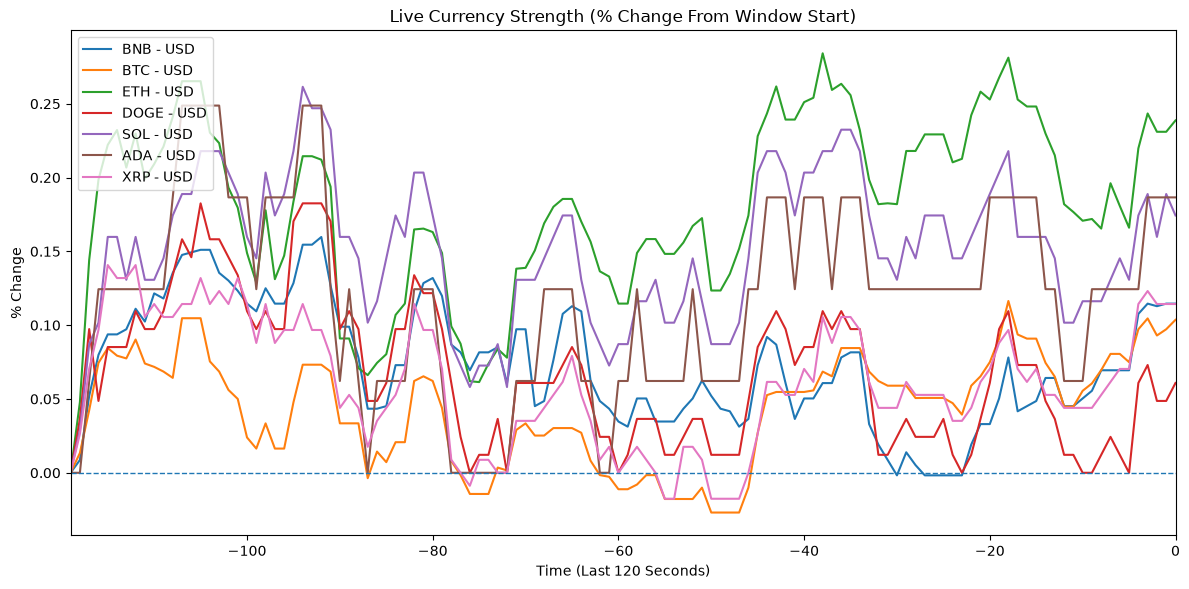

Stopped.


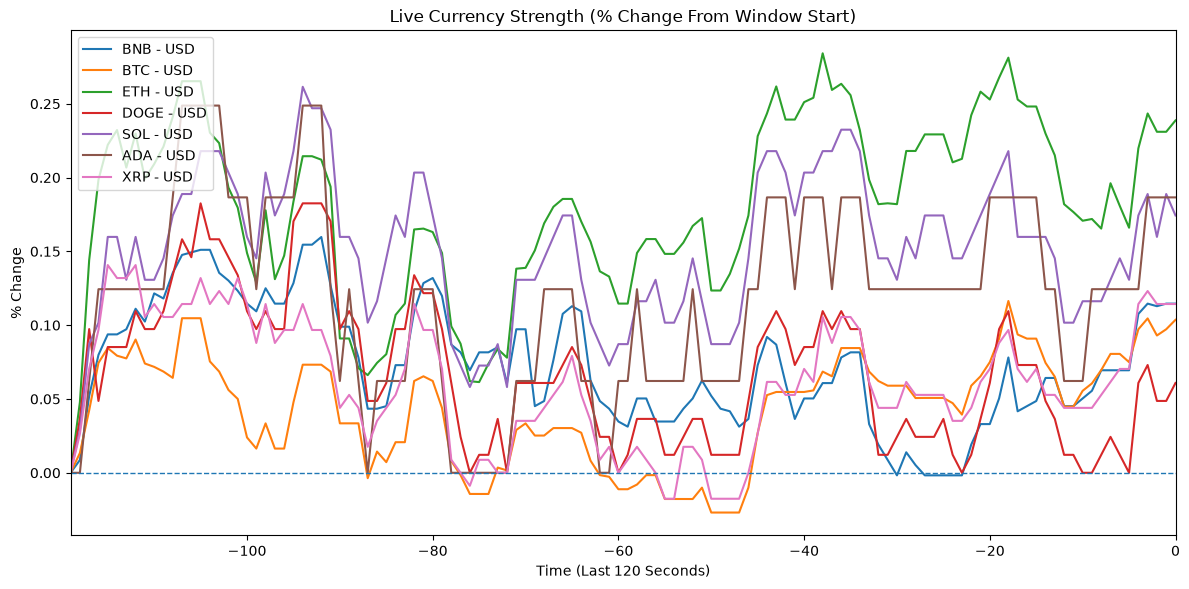

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

try:
    while True:
        if order_books:
            # Update histories
            for stream, book in order_books.items():
                if not book["bids"]: continue
                best_bid = float(book["bids"][0][0])
                price_history[stream].append(best_bid)

            # Draw
            ax.clear()

            for stream, history in price_history.items():
                if len(history) < 2: continue
                base = history[0]
                pct_change = [(price / base - 1) * 100 for price in history]
                pair_name = format_pair(stream)
                x_axis = list(range(-len(history) + 1, 1))

                ax.plot(x_axis, pct_change, label=pair_name)

            ax.axhline(0,linestyle="--",linewidth=1)
            ax.set_xlim(-HISTORY_LEN + 1, 0)
            ax.set_title("Live Currency Strength (% Change From Window Start)")

            ax.set_ylabel("% Change")
            ax.set_xlabel("Time (Last 120 Seconds)")
            ax.legend(loc="upper left")

            plt.tight_layout()

            clear_output(wait=True)
            display(fig)

        time.sleep(1)

except KeyboardInterrupt:
    print("Stopped.")
